# Quick Start: Iterating over splits of gift-eval datasets
First lets check the names of all the datasets in the `gift-eval` directory.

Make sure you download the gift-eval benchmark and set the `GIFT-EVAL` environment variable correctly before running this notebook.



In [1]:
import os
from data.gift_eval.src.gift_eval.data import Dataset
import numpy as np
from dotenv import load_dotenv
from pathlib import Path
from gluonts.dataset.util import to_pandas
import matplotlib.pyplot as plt
from matplotlib import cm
import pandas as pd
# Load environment variables
load_dotenv()

# Get the GIFT_EVAL path from environment variables
gift_eval_path = os.getenv("GIFT_EVAL")

if gift_eval_path:
    # Convert to Path object for easier manipulation
    gift_eval_path = Path(gift_eval_path)

    # Get all subdirectories (dataset names) in the GIFT_EVAL path
    dataset_names = []
    for dataset_dir in gift_eval_path.iterdir():
        if dataset_dir.name.startswith("."):
            continue
        if dataset_dir.is_dir():
            freq_dirs = [d for d in dataset_dir.iterdir() if d.is_dir()]
            if freq_dirs:
                for freq_dir in freq_dirs:
                    dataset_names.append(f"{dataset_dir.name}/{freq_dir.name}")
            else:
                dataset_names.append(dataset_dir.name)

    print("Available datasets in GIFT_EVAL:")
    for name in sorted(dataset_names):
        print(f"- {name}")
else:
    print(
        "GIFT_EVAL path not found in environment variables. Please check your .env file."
    )

ModuleNotFoundError: No module named 'data'

In [7]:
df_results = pd.DataFrame()
extra_cols = ['dataset', 'domain', 'num_variates']
model_names = [
    "tabpfn_ts", "YingLong_300m", "toto", "TiRex", "tempo_ensemble", 
    "timesfm_2_0_500m", "sundial_base_128m", "TTM", "chronos_base",
    "chronos_bolt_base", "feedforward", "tabdpt_ts", "Toto_Open_Base_1.0",
]
for model_name in model_names:
    results_path = f"./data/gift_eval/results/{model_name}/all_results.csv"
    df = pd.read_csv(results_path)
    if df_results.empty:
        df_results[extra_cols] = df[extra_cols]
    df_results = pd.merge(df_results, df[['dataset', 'eval_metrics/MASE[0.5]']], on='dataset', how='outer')
    df_results.rename(columns={'eval_metrics/MASE[0.5]': model_name}, inplace=True)

df_results['winner'] = df_results[model_names].idxmin(axis=1)

df_results[df_results['num_variates']>1]

,dataset,domain,num_variates,tabpfn_ts,YingLong_300m,toto,TiRex,tempo_ensemble,timesfm_2_0_500m,sundial_base_128m,TTM,chronos_base,chronos_bolt_base,feedforward,tabdpt_ts,Toto_Open_Base_1.0,winner
0,bitbrains_fast_storage/5T/long,Web/CloudOps,2,1.152664,1.009582,0.896967,0.918888,1.133234,0.979985,1.011070,0.939446,NaN,0.948321,NaN,NaN,0.896967,toto
1,bitbrains_fast_storage/5T/medium,Web/CloudOps,2,1.307634,1.071829,0.984744,0.994892,1.371458,1.075077,1.107872,1.068926,NaN,1.062440,NaN,NaN,0.984744,toto
2,bitbrains_fast_storage/5T/short,Web/CloudOps,2,0.998051,0.803221,0.671779,0.691979,1.027908,0.731319,0.740082,0.736152,NaN,0.752396,NaN,NaN,0.671779,toto
3,bitbrains_fast_storage/H/short,Web/CloudOps,2,1.184095,1.116042,0.944750,1.070637,1.405802,1.094683,1.149901,1.203415,NaN,1.069866,NaN,NaN,0.944750,toto
4,bitbrains_rnd/5T/long,Web/CloudOps,2,3.874638,3.470029,3.336748,3.341029,3.668935,3.599921,3.522494,3.503298,NaN,3.397353,NaN,NaN,3.336748,toto
5,bitbrains_rnd/5T/medium,Web/CloudOps,2,4.831155,4.498292,4.416975,4.393507,4.779265,4.594672,4.562192,4.529740,NaN,4.449086,NaN,NaN,4.416975,TiRex
6,bitbrains_rnd/5T/short,Web/CloudOps,2,2.030880,1.785717,1.649742,1.664585,2.176023,1.769327,1.714668,1.752523,NaN,1.705398,NaN,NaN,1.649742,toto
7,bitbrains_rnd/H/short,Web/CloudOps,2,6.680151,5.891559,5.637955,5.860061,6.339388,5.986560,5.979680,6.063022,NaN,5.896931,NaN,NaN,5.637955,toto
8,bizitobs_application/10S/long,Web/CloudOps,2,3.094253,4.599799,3.274733,3.686197,1.105182,4.074521,3.705244,3.805221,NaN,10.483797,NaN,3.466057,3.274733,tempo_ensemble
9,bizitobs_application/10S/medium,Web/CloudOps,2,2.490062,3.868127,2.303904,2.784767,1.116547,3.081612,2.856536,3.053296,NaN,9.720343,NaN,2.798533,2.303904,tempo_ensemble


In [8]:
df_results.groupby('num_variates')['winner'].value_counts()#.sort_values(ascending=False)

num_variates  winner           
1             timesfm_2_0_500m     14
              tempo_ensemble       11
              TiRex                10
              TTM                   7
              chronos_bolt_base     4
              tabpfn_ts             3
              toto                  3
              sundial_base_128m     2
2             toto                 10
              tempo_ensemble        3
              TiRex                 1
7             tempo_ensemble       15
              TTM                   2
              toto                  2
              chronos_bolt_base     1
              TiRex                 1
              sundial_base_128m     1
21            timesfm_2_0_500m      3
              TiRex                 1
              chronos_bolt_base     1
              sundial_base_128m     1
              tempo_ensemble        1
Name: count, dtype: int64

In [9]:
df_results.groupby('num_variates').count()['dataset']

num_variates
1     54
2     14
7     22
21     7
Name: dataset, dtype: int64

# Loading Datasets

We provide a simple class, called `Dataset`, to load each dataset in our benchmark following the gluonts interface. It is highly recommended to use this class to split the data to train/val/test for compatibility with the evaluation framework and other baselines in the leaderboard. You don't have to stick to gluonts interface though as you can easily implement a wrapper class to load the data iterator in a different format than gluonts.

This class provides the following properties:

- `training_dataset`: The training dataset.
- `validation_dataset`: The validation dataset.
- `test_data`: The test dataset.

Note that timeseries modality splits the data to train/val/test on the time dimension rather than the series dimension. Thus each of these splits utilize same series but different time indices. The number of windows for rolling evaluation is determined by the `Dataset` class. 

The training_dataset and validation_dataset are iterators where each element is a dictionary with the following keys:

- `start`: the start time of the window
- `target`: the target values of the window
- `item_id`: the id of the series
- `freq`: The frequency of the series
- `past_feat_dynamic_real`: [If exists] the past feature dynamic real values of the window


The test_data is a tuple with two dictionaries. First for the context, second for the forecast horizon, where each dictionary contains the same keys as above.


## Example Usage: M4 Monthly

Lets load and inspect the M4 Monthly dataset using our `Dataset` class.

Dataset frequency:  D
self.freq = D, to_offset = D, multiplier = 1,final freq = D
Prediction length:  30
Number of windows in the rolling evaluation:  2
Keys in the test data:  dict_keys(['item_id', 'start', 'freq', 'target'])


Context Item id:  item_0
Context Start Date:  2020-01-01
Context Frequency:  D
Keys in the test data:  dict_keys(['item_id', 'start', 'freq', 'target'])


Context Item id:  item_0
Context Start Date:  2020-01-01
Context Frequency:  D
Keys in the test data:  dict_keys(['item_id', 'start', 'freq', 'target'])


Context Item id:  item_0
Context Start Date:  2020-11-02
Context Frequency:  D


/tmp/ipykernel_881253/443102459.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20b', 27).colors  # Use a colormap with more than 30 colors


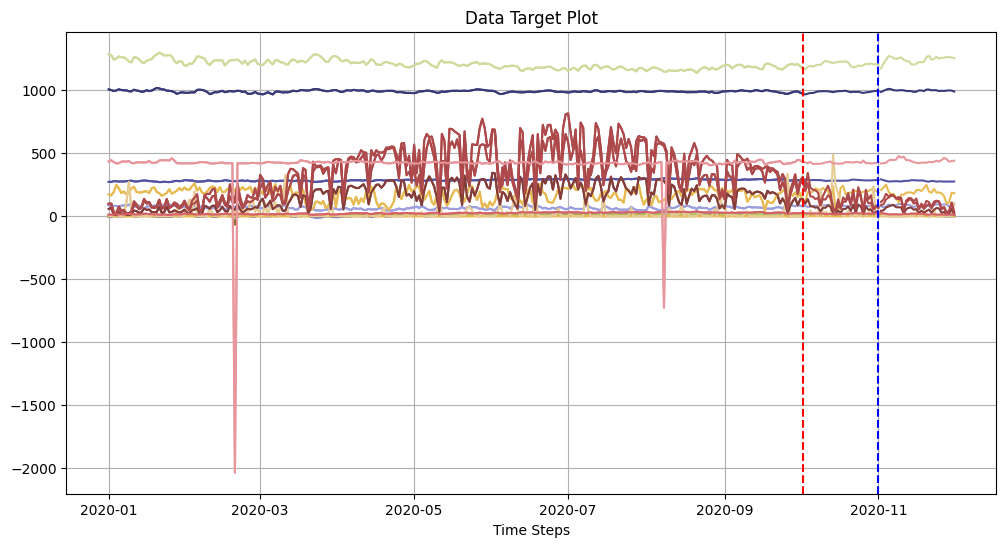

Dataset frequency:  W-THU
self.freq = W-THU, to_offset = W-THU, multiplier = 1,final freq = W
Prediction length:  8
Number of windows in the rolling evaluation:  2
Keys in the test data:  dict_keys(['item_id', 'start', 'freq', 'target'])


Context Item id:  item_0
Context Start Date:  2016-07-01/2016-07-07
Context Frequency:  W-THU
Keys in the test data:  dict_keys(['item_id', 'start', 'freq', 'target'])


Context Item id:  item_0
Context Start Date:  2016-07-01/2016-07-07
Context Frequency:  W-THU
Keys in the test data:  dict_keys(['item_id', 'start', 'freq', 'target'])


Context Item id:  item_0
Context Start Date:  2018-03-02/2018-03-08
Context Frequency:  W-THU


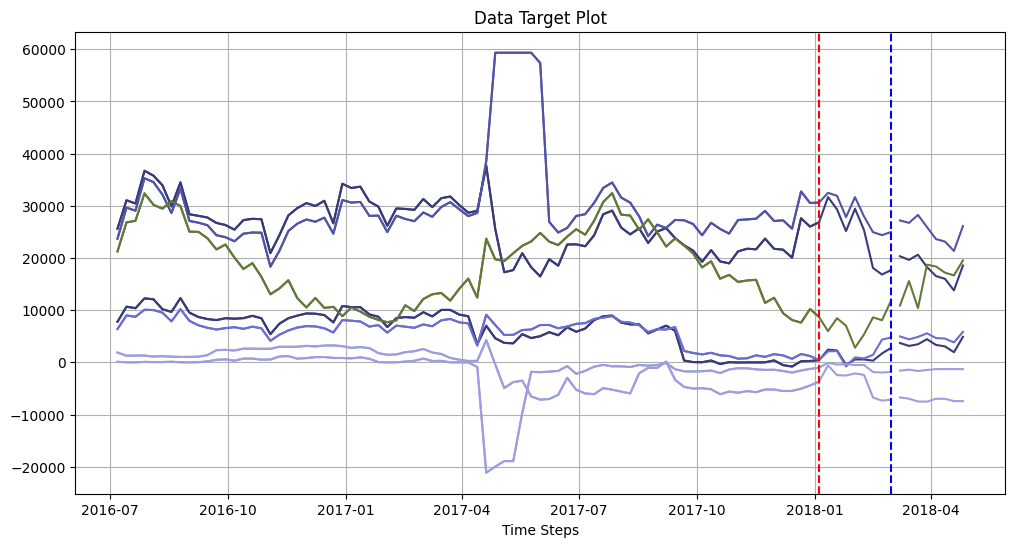

In [10]:
for ds_name in ["jena_weather/D", "ett2/W"]:  # Name of the dataset
    to_univariate = False  # Whether to convert the data to univariate
    term = "short"  # Term of the dataset
    dataset = Dataset(name=ds_name, term=term, to_univariate=to_univariate)
    print("Dataset frequency: ", dataset.freq)
    print("Prediction length: ", dataset.prediction_length)
    print("Number of windows in the rolling evaluation: ", dataset.windows)


    train_data_iter = dataset.training_dataset
    val_data_iter = dataset.validation_dataset
    test_split_iter = dataset.test_data

    train_data = next(iter(train_data_iter))
    val_data = next(iter(val_data_iter))
    test_data = next(iter(test_split_iter))[1]

    plt.figure(figsize=(12, 6))
    next_begins = 0
    num_dimensions = train_data["target"].shape[0]
    colors = cm.get_cmap('tab20b', 27).colors  # Use a colormap with more than 30 colors

    for data in [train_data, val_data, test_data]:
        print("Keys in the test data: ", data.keys())
        print("\n\nContext Item id: ", data["item_id"])
        print("Context Start Date: ", data["start"])
        print("Context Frequency: ", data["freq"])
        # print("Context Last 10 target values: ", data["target"][-10:])
        
        for dim in range(num_dimensions):
            plt.plot(
                pd.date_range(
                    start=data["start"].to_timestamp(), periods=len(data["target"].T), freq=data["freq"]
                ),
                # np.arange(next_begins, next_begins + len(data["target"].T)),
                data["target"][dim].T,
                label=f"Dim {dim + 1}" if next_begins == 0 else None,
                color=colors[dim % len(colors)],
            )
        next_begins += len(data["target"].T)

    train_end_time = pd.date_range(
        start=train_data["start"].to_timestamp(), periods=len(train_data["target"].T), freq=train_data["freq"]
    )[-1]
    val_end_time = pd.date_range(
        start=val_data["start"].to_timestamp(), periods=len(val_data["target"].T), freq=val_data["freq"]
    )[-1]

    plt.axvline(x=train_end_time, color='red', linestyle='--', label='Train Ends')
    plt.axvline(x=val_end_time, color='blue', linestyle='--', label='Validation Ends')

    plt.grid(which="both")
    plt.title("Data Target Plot")
    plt.xlabel("Time Steps")
    # plt.legend()
    plt.show()
